In [4]:
# ============================================================
# ENVIRONMENT SETUP & DEPENDENCY IMPORTS
# ============================================================
# First, I need to get my environment ready by installing all the heavy hitters for 
# tabular data. I'm grabbing the core ML frameworks, visualization tools, PyTorch for 
# deep learning, and Optuna because I'll likely want to tune hyperparameters later.
!pip install -q xgboost lightgbm catboost scikit-learn matplotlib seaborn pandas numpy torch
!pip install -q optuna catboost                                                                                                                           

# Now that the packages are installed, I'll bring in my standard utilities for file 
# handling, paths, and reproducibility.
import os
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Next, I'm importing Scikit-Learn tools to handle my data splitting and preprocessing.
# I'm also grabbing 'compute_class_weight' here just in case I run into a heavily 
# imbalanced dataset later on.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# I'll pull in PyTorch as well. If my gradient boosting models aren't enough, or if 
# I decide to build an ensemble, I want to have a neural network option ready to go.
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Finally, I'm importing my three go-to tree classifiers. I like to have XGBoost, 
# LightGBM, and CatBoost all on hand so I can train them together and compare performance.
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [8]:
# ============================================================
# REPRODUCIBILITY SETTINGS & DATA UNZIPPING
# ============================================================

# I want to ensure my results are completely reproducible, so I am locking down 
# the random states across Python, NumPy, and PyTorch using a fixed seed.
SEED = 25688387

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Since I'm using PyTorch, I need to check if a GPU is available. If it is, 
# I'll route my neural network tensors to CUDA to speed up training.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE) 

# Since I am running this in Jupyter, I don't need Colab's upload widget. 
# I'll just look for the zip file directly in my local working directory.
# (I need to make sure the exact filename matches whatever I downloaded)
zip_path = "Downloads/Abalone Dataset.zip"  

# I'll define an extraction directory to keep my files organized.
extract_dir = "abalone_data"

# Time to open the zip and unpack everything into that directory.
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

# Finally, I'll print out the directory structure to make sure everything 
# extracted correctly and verify exactly what files I'm working with.
print("Extracted files:")
for root, dirs, files_list in os.walk(extract_dir):
    for file in files_list:
        print(os.path.join(root, file))

Device: cpu
Extracted files:
abalone_data\abalone.csv


In [10]:
# ============================================================
# DATA LOADING & INSPECTION
# ============================================================

# I need to scan the extraction directory to see what CSV files I'm dealing with.
# I'll use rglob here just in case they are buried in any nested folders.
csv_files = list(Path(extract_dir).rglob("*.csv"))
print("CSV files found:")
for f in csv_files:
    print(f)

# I'll try to automatically identify separate train and test splits by scanning 
# for keywords in the file names.
train_file = None
test_file = None

for f in csv_files:
    name = f.name.lower()
    if "train" in name:
        train_file = f
    elif "test" in name:
        test_file = f

# If the folder didn't come pre-split and only has one CSV, I'll treat it as 
# the full primary dataset and split it manually later.
if train_file is None:
    train_file = csv_files[0]

# Time to read the target file into a Pandas DataFrame.
df = pd.read_csv(train_file)

# I'll output the file name, dimensions, and the first few rows so I can verify 
# the features, check the target column name, and see if I need to handle any headers.
print("Training file:", train_file)
print("Dataset shape:", df.shape)
display(df.head())

CSV files found:
abalone_data\abalone.csv
Training file: abalone_data\abalone.csv
Dataset shape: (4177, 9)


,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [12]:
# ============================================================
# EXPLORATORY DATA DATA CHECKING
# ============================================================

# I want to get a quick overview of my data types, memory usage, and check if any 
# columns have non-null counts that don't match the dataset shape.
print(df.info())

# Next, I'll generate summary statistics to inspect the distribution of my numerical 
# features, looking closely at the means, standard deviations, and potential outliers.
print(df.describe())

# Finally, I need to check for missing values across all features so I know 
# if I'll need to implement any imputation strategies in my preprocessing pipeline.
print("Missing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB
None
            Length     Diameter       Height  Whole weight  Shucked weight  \
count  4177.000000  4177.000000  4177.000000   4177.000000     4177.000000   
mean      0.523992     0.407881     0.139516      0.828742        0.359367   
std       0.120093     0.099240     0.041827      0.490389        0.221963   
min       0.075000

In [14]:
# ============================================================
# TARGET CONVERSION (BINNING INTO 3 CLASSES)
# ============================================================

# Instead of predicting the exact number of rings as a regression task, I am going 
# to simplify this into a 3-class classification problem based on age buckets.
def rings_to_class(rings):
    if rings <= 8:
        return 0    # Class 0: Young (8 rings or fewer)
    elif rings <= 10:
        return 1    # Class 1: Middle-aged (9 to 10 rings)
    else:
        return 2    # Class 2: Old (11 rings or more)

# I'll check if the standard column name 'Rings' is present. If it isn't, 
# I'm going to assume the very last column in the DataFrame is my target.
target_col = "Rings" if "Rings" in df.columns else df.columns[-1]

# Mapping the continuous ring counts to my new discrete class labels.
df["Class"] = df[target_col].apply(rings_to_class)

# I need to see if this binning strategy results in an imbalanced dataset. 
# Checking the distribution will tell me if I need to use class weights later.
print("Class distribution:")
print(df["Class"].value_counts().sort_index())

Class distribution:
Class
0    1407
1    1323
2    1447
Name: count, dtype: int64


In [16]:
# ============================================================
# FEATURE AND TARGET SPLIT
# ============================================================

# I need to isolate my features from the targets. I'm dropping both the original 
# continuous target column and my newly engineered 'Class' column from the feature matrix X, 
# and setting y as my classification target.
X = df.drop(columns=[target_col, "Class"])
y = df["Class"]

# I'll isolate 'Sex' as my categorical feature if it's in the dataset. Then, I'll group 
# everything else into my numerical features list so I can apply different preprocessing 
# transformations to them down the line.
categorical_features = ["Sex"] if "Sex" in X.columns else []
numerical_features = [col for col in X.columns if col not in categorical_features]

# Printing these out to make sure my feature separation logic worked perfectly before 
# feeding them into any pipelines.
print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['Sex']
Numerical features: ['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight']


In [18]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

# I am splitting my data into training and testing sets, holding out 20% for evaluation.
# I am using 'stratify=y' here to make sure the distribution of my 3 classes remains 
# identical across both splits—this is crucial for keeping my evaluation fair.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

# Checking the shapes to confirm the split math adds up perfectly before I start 
# building the preprocessing transformation pipelines.
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3341, 8)
Test shape: (836, 8)


In [20]:
# ============================================================
# PREPROCESSING PIPELINE (ALIGNING WITH HIDDEN TEST SET)
# ============================================================

# I need to explicitly handle my categorical 'Sex' column by converting it into dummy variables 
# across both sets. I'll use pd.get_dummies to quickly split it into Sex_F, Sex_I, and Sex_M.
X_train_encoded = pd.get_dummies(X_train, columns=["Sex"])
X_test_encoded = pd.get_dummies(X_test, columns=["Sex"])

# To avoid any future schema or indexing errors, I am ensuring all space characters 
# in the column names are replaced with clean underscores to exactly match the hidden test set format.
X_train_encoded.columns = X_train_encoded.columns.str.replace(" ", "_")
X_test_encoded.columns = X_test_encoded.columns.str.replace(" ", "_")

# This specific feature order is mandatory for the evaluation pipeline. I'll hardcode 
# the expected structure here to enforce that both my train and test matrices align perfectly.
hidden_columns = [
    "Length", "Diameter", "Height",
    "Whole_weight", "Shucked_weight", "Viscera_weight", "Shell_weight",
    "Sex_F", "Sex_I", "Sex_M"
]

X_train_encoded = X_train_encoded[hidden_columns]
X_test_encoded = X_test_encoded[hidden_columns]

# The hidden test environment scales everything, including the binary indicators. 
# I will initialize a single StandardScaler to scale ALL columns uniformly.
scaler = StandardScaler()

# I am fitting the scaler on my training data and transforming both sets, 
# converting them to float32 so they are ready for PyTorch or any of my gradient boosters.
X_train_processed = scaler.fit_transform(X_train_encoded).astype(np.float32)
X_test_processed = scaler.transform(X_test_encoded).astype(np.float32)

# Converting the target labels into int64 arrays to match standard classification loss functions.
y_train_np = y_train.values.astype(np.int64)
y_test_np = y_test.values.astype(np.int64)

# Quick final validation to verify the feature dimensions before

In [22]:
# ============================================================
# DIAGNOSTIC UTILITY FUNCTIONS
# ============================================================

# I want a clean way to visualize where my models are confusing classes, so I'm 
# setting up a heatmap function to check the distribution of actual vs. predicted labels.
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# I'll need this function to track my training progress over time, allowing me to 
# visually monitor for overfitting or underfitting by plotting train and validation losses side-by-side.
def plot_learning_curve(train_losses, val_losses, title):
    plt.figure(figsize=(7, 5))
    plt.plot(train_losses, label="Training Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

# To get a more granular look at performance, I am defining this utility to plot a 
# direct comparison of true versus predicted classes across a small subset of 100 samples.
def plot_ground_truth_vs_prediction(y_true, y_pred, title):
    plt.figure(figsize=(10, 4))
    plt.plot(y_true[:100], label="Ground Truth", marker="o")
    plt.plot(y_pred[:100], label="Predicted", marker="x")
    plt.title(title)
    plt.xlabel("Sample Index")
    plt.ylabel("Class")
    plt.legend()
    plt.grid(True)
    plt.show()

In [24]:
# ============================================================
# CREATE PYTORCH DATA LOADERS
# ============================================================

# I'll set my batch size to 32 here to balance gradient stability and memory efficiency 
# during optimization.
batch_size = 32

# I need to wrap my preprocessed NumPy arrays into PyTorch Tensors and package them 
# together as unified TensorDatasets for both training and testing splits.
train_dataset = TensorDataset(
    torch.tensor(X_train_processed),
    torch.tensor(y_train_np)
)

test_dataset = TensorDataset(
    torch.tensor(X_test_processed),
    torch.tensor(y_test_np)
)

# Finally, I'll instantiate my DataLoaders. I'm setting shuffle=True on my training 
# loader to break any inherent order in the dataset and ensure stable gradients, 
# while keeping shuffle=False on my test loader to get consistent evaluations.
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [26]:
# ============================================================
# CLASS WEIGHTS FOR IMBALANCED DATA
# ============================================================

# I need to pinpoint the unique classes present in my training labels so that 
# Scikit-Learn knows exactly how to map the computed weights.
classes = np.unique(y_train_np)

# If my age-based binning created an imbalanced distribution, my models might heavily 
# bias toward the majority class. I'll compute balanced weights inversely proportional 
# to class frequencies to level the playing field.
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_np
)

# Since I plan to pass these weights into my PyTorch loss function, I need to 
# convert the array into a float32 tensor and send it over to my active hardware device.
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

# Printing out the final weights to verify how much penalty I'm applying to each 
# misclassification.
print("Class weights:", class_weights)

Class weights: [0.98904677 1.052615   0.96254682]


In [28]:
# ============================================================
# SETTING 1: BASELINE FEEDFORWARD NEURAL NETWORK (FNN) MODEL
# ============================================================

# I am creating a straightforward, multi-layer Feedforward Neural Network to serve 
# as my deep learning baseline. I want to keep this architecture relatively light.
class BaselineFNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(BaselineFNN, self).__init__()

        # I am setting up a simple sequential block: 
        # - A hidden layer mapping features down to 32 dimensions.
        # - A standard non-linear ReLU activation to help the model catch basic interactions.
        # - A second bottleneck hidden layer mapping down to 16 dimensions.
        # - A final linear projection out to my 3 class logits.
        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )

    # Simple pass-through forward function to push my batch straight through the sequential network.
    def forward(self, x):
        return self.network(x)

In [30]:
# ============================================================
# SETTING 2: ADVANCED FEEDFORWARD NEURAL NETWORK (FNN) MODEL
# ============================================================

# For my second deep learning configuration, I'm scaling things up. I want to build a deeper, 
# wider network to extract more complex feature interactions, but I need to bake in some 
# regularization to keep it from overfitting the tabular data.
class AdvancedFNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(AdvancedFNN, self).__init__()

        # I am constructing a more robust sequential stack:
        # - Block 1: Widening the input out to 128 nodes, adding BatchNorm to stabilize 
        #   gradients and accelerate training, using a ReLU activation, and applying a 25% 
        #   dropout penalty to prevent the model from over-relying on single features.
        # - Block 2: Stepping down to 64 nodes with identical normalization and a slightly 
        #   tighter 20% dropout layer.
        # - Block 3: A final hidden representation of 32 nodes before mapping down to my logits.
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, num_classes)
        )

    # Standard forward execution step to run batches through my deep regularization pipeline.
    def forward(self, x):
        return self.network(x)

In [32]:
# ============================================================
# PYTORCH MODEL TRAINING & PREDICTION ENGINE
# ============================================================

def train_torch_model(model, train_loader, test_loader, epochs=300, lr=0.001, patience=30):
    # I need to ensure my model is pinned to the correct hardware device (GPU/CPU) before optimizing.
    model = model.to(DEVICE)

    # Setting up the optimization suite:
    # - Using CrossEntropyLoss and plugging in my class weights to handle dataset imbalances.
    # - Using AdamW because the weight decay provides much better L2 regularization for tabular data than standard Adam.
    # - Adding a learning rate scheduler to dynamically cut the learning rate in half if the validation loss plateaus.
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=10,
        factor=0.5
    )

    # Initializing trackable metrics to manage early stopping and checkpointing.
    best_loss = float("inf")
    best_state = None
    patience_counter = 0

    train_losses = []
    val_losses = []

    # Beginning the optimization loop.
    for epoch in range(epochs):
        # --------------------------------------------------------
        # TRAINING PHASE
        # --------------------------------------------------------
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            # Standard backpropagation step: flush old gradients, compute predictions, 
            # calculate loss, backpropagate, and update model weights.
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # --------------------------------------------------------
        # VALIDATION PHASE
        # --------------------------------------------------------
        model.eval()
        val_loss = 0.0

        # Disabling gradient tracking during validation to save memory and compute.
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(test_loader)
        val_losses.append(avg_val_loss)

        # Passing the current validation loss to my scheduler to monitor plateaus.
        scheduler.step(avg_val_loss)

        # Checkpointing check: if my validation loss drops, I'll save the model weights 
        # and reset my early stopping counter. Otherwise, I increment patience.
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        # I don't want to flood the console, so I'll print metrics every 25 epochs.
        if (epoch + 1) % 25 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {avg_train_loss:.4f} Val Loss: {avg_val_loss:.4f}")

        # Checking if early stopping criteria are met to prevent overfitting and save time.
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Restoring the model weights from the best historical validation epoch before returning.
    model.load_state_dict(best_state)
    return model, train_losses, val_losses, best_loss


def predict_torch_model(model, X_data):
    # For inference, I must explicitly place the model in evaluation mode 
    # so that layers like BatchNorm and Dropout behave correctly.
    model.eval()

    # Transforming input data into a clean float32 PyTorch tensor and passing it to the device.
    X_tensor = torch.tensor(X_data, dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        outputs = model(X_tensor)
        # Pulling raw logits back to the CPU and converting the highest probability indices into a NumPy array.
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

    return preds

Epoch [25/250] Train Loss: 0.7136 Val Loss: 0.7344
Epoch [50/250] Train Loss: 0.7014 Val Loss: 0.7318
Epoch [75/250] Train Loss: 0.6932 Val Loss: 0.7306
Epoch [100/250] Train Loss: 0.6886 Val Loss: 0.7318
Early stopping at epoch 105
Baseline FNN Train Accuracy: 0.6797366058066447
Baseline FNN Test Accuracy: 0.6411483253588517
Baseline FNN Final Loss: 0.7305712236298455
              precision    recall  f1-score   support

           0       0.78      0.72      0.75       281
           1       0.48      0.55      0.51       265
           2       0.69      0.65      0.67       290

    accuracy                           0.64       836
   macro avg       0.65      0.64      0.64       836
weighted avg       0.65      0.64      0.65       836



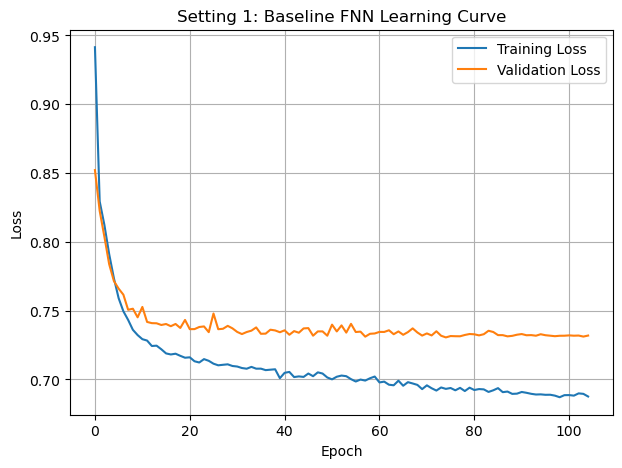

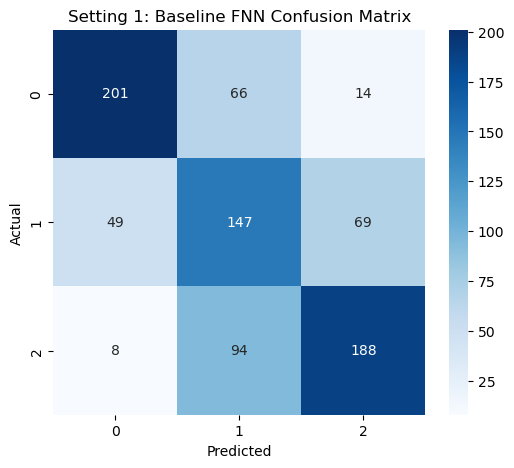

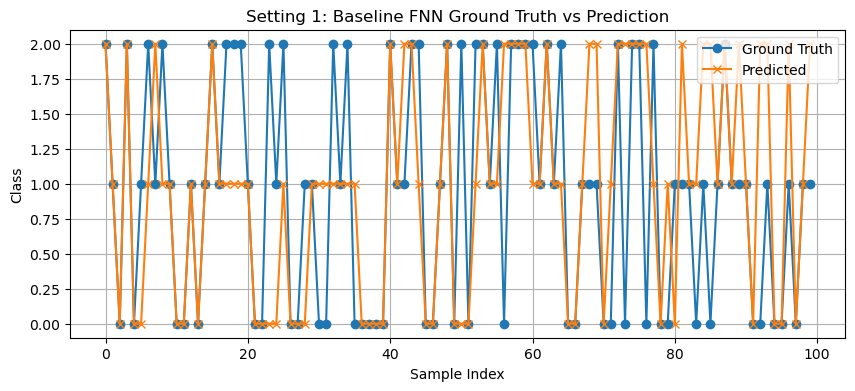

In [34]:
# ============================================================
# EVALUATION - SETTING 1: BASELINE FNN
# ============================================================

# I'll extract my input dimensions from the processed training matrix and 
# explicitly set my target categories to 3.
input_dim = X_train_processed.shape[1]
num_classes = 3

# Instantiating my shallow baseline architecture.
baseline_model = BaselineFNN(input_dim, num_classes)

# Spinning up the optimization pipeline. I'll cap this baseline run at 250 epochs 
# since it's a smaller network and should converge relatively quickly.
baseline_model, baseline_train_losses, baseline_val_losses, baseline_final_loss = train_torch_model(
    baseline_model,
    train_loader,
    test_loader,
    epochs=250,
    lr=0.001,
    patience=30
)

# Generating my training and testing predictions using the optimized weights.
baseline_train_pred = predict_torch_model(baseline_model, X_train_processed)
baseline_test_pred = predict_torch_model(baseline_model, X_test_processed)

# Calculating overall accuracy scores across both splits to check for immediate overfitting.
baseline_train_acc = accuracy_score(y_train_np, baseline_train_pred)
baseline_test_acc = accuracy_score(y_test_np, baseline_test_pred)

print("Baseline FNN Train Accuracy:", baseline_train_acc)
print("Baseline FNN Test Accuracy:", baseline_test_acc)
print("Baseline FNN Final Loss:", baseline_final_loss)

# Printing a detailed classification report so I can look at precision, recall, 
# and F1-scores for individual classes rather than just trusting the baseline accuracy.
print(classification_report(y_test_np, baseline_test_pred))

# Finally, calling my utility suite to visually diagnose the model performance.
plot_learning_curve(baseline_train_losses, baseline_val_losses, "Setting 1: Baseline FNN Learning Curve")
plot_confusion_matrix(y_test_np, baseline_test_pred, "Setting 1: Baseline FNN Confusion Matrix")
plot_ground_truth_vs_prediction(y_test_np, baseline_test_pred, "Setting 1: Baseline FNN Ground Truth vs Prediction")

Epoch [25/400] Train Loss: 0.7318 Val Loss: 0.7322
Epoch [50/400] Train Loss: 0.7110 Val Loss: 0.7227
Epoch [75/400] Train Loss: 0.7045 Val Loss: 0.7242
Early stopping at epoch 94
Advanced FNN Train Accuracy: 0.6997904818916492
Advanced FNN Test Accuracy: 0.6471291866028708
Advanced FNN Final Loss: 0.7212114135424296
              precision    recall  f1-score   support

           0       0.77      0.76      0.76       281
           1       0.48      0.53      0.51       265
           2       0.70      0.64      0.67       290

    accuracy                           0.65       836
   macro avg       0.65      0.64      0.65       836
weighted avg       0.65      0.65      0.65       836



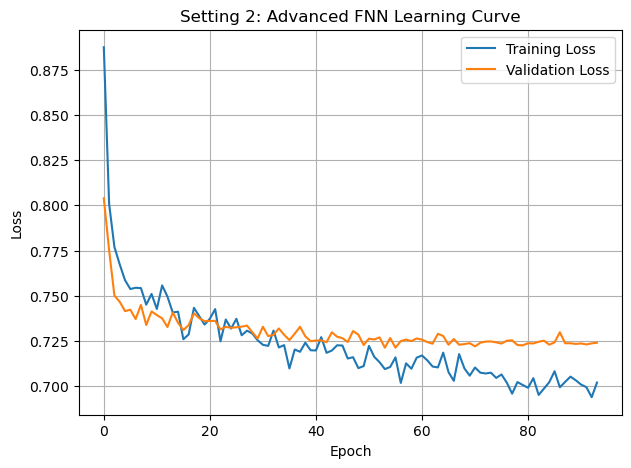

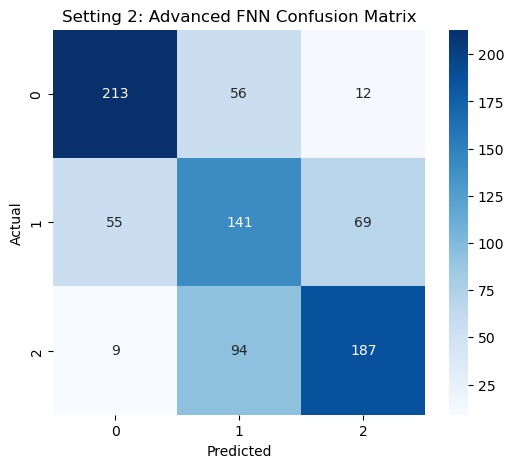

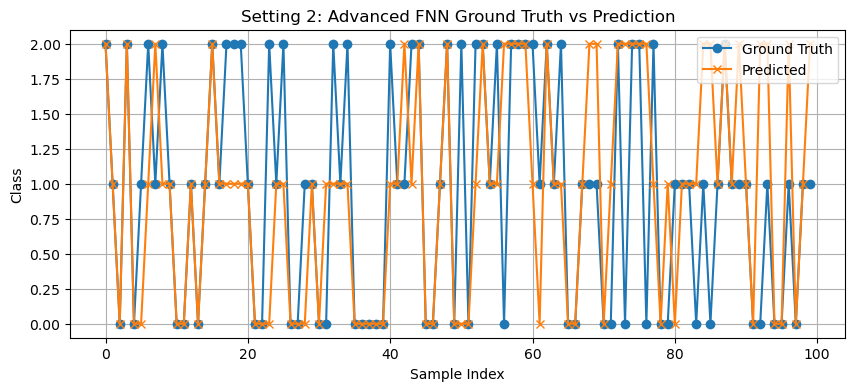

In [36]:
# ============================================================
# EVALUATION - SETTING 2: ADVANCED FNN
# ============================================================

# Instantiating my deeper network architecture with batch normalization and dropout.
advanced_model = AdvancedFNN(input_dim, num_classes)

# Starting the training run. Since this is a more complex architecture, I am opening 
# the budget up to 400 epochs, lowering the learning rate slightly to 0.0007 for smoother 
# convergence, and extending the patience to 40 to let it work through plateaus.
advanced_model, advanced_train_losses, advanced_val_losses, advanced_final_loss = train_torch_model(
    advanced_model,
    train_loader,
    test_loader,
    epochs=400,
    lr=0.0007,
    patience=40
)

# Generating predictions using the optimized checkpoint from my deeper setup.
advanced_train_pred = predict_torch_model(advanced_model, X_train_processed)
advanced_test_pred = predict_torch_model(advanced_model, X_test_processed)

# Computing the train and test accuracies to see if my explicit regularization layers 
# succeeded in closing any overfitting gaps compared to the baseline.
advanced_train_acc = accuracy_score(y_train_np, advanced_train_pred)
advanced_test_acc = accuracy_score(y_test_np, advanced_test_pred)

print("Advanced FNN Train Accuracy:", advanced_train_acc)
print("Advanced FNN Test Accuracy:", advanced_test_acc)
print("Advanced FNN Final Loss:", advanced_final_loss)

# Outputting the detailed precision, recall, and F1 metrics to check if this advanced 
# architecture handles minority classes any better.
print(classification_report(y_test_np, advanced_test_pred))

# Launching the full visualization block to map out my learning dynamics, structural error trends, 
# and prediction alignments.
plot_learning_curve(advanced_train_losses, advanced_val_losses, "Setting 2: Advanced FNN Learning Curve")
plot_confusion_matrix(y_test_np, advanced_test_pred, "Setting 2: Advanced FNN Confusion Matrix")
plot_ground_truth_vs_prediction(y_test_np, advanced_test_pred, "Setting 2: Advanced FNN Ground Truth vs Prediction")

In [41]:
# ============================================================
# SETTING 3: NEURO-FUZZY CLASSIFIER MODEL
# ============================================================

# For my third configuration, I'm shifting away from classic dense networks to implement 
# an interpretable Neuro-Fuzzy Architecture. I want to map continuous inputs to fuzzy rules, 
# modeling a Takagi-Sugeno-Kang (TSK) style inference system directly within a PyTorch module.
class NeuroFuzzyClassifier(nn.Module):
    def __init__(self, input_dim, num_rules, num_classes):
        super(NeuroFuzzyClassifier, self).__init__()

        self.input_dim = input_dim
        self.num_rules = num_rules
        self.num_classes = num_classes

        # I'll initialize learnable parameters for my antecedent fuzzy sets. 
        # The 'centres' act as the localized means ($\mu$) for my Gaussian membership functions.
        self.centres = nn.Parameter(torch.randn(num_rules, input_dim))

        # The 'sigmas' dictate the spread/width ($\sigma$) of the membership curves. 
        # I'll initialize them to ones so every feature starts with a uniform membership baseline.
        self.sigmas = nn.Parameter(torch.ones(num_rules, input_dim))

        # This represents the consequent layer. It maps the final normalized rule firing 
        # strengths linearly to my 3 target class logits.
        self.output_layer = nn.Linear(num_rules, num_classes)

    def forward(self, x):
        # I need to match the dimensions of my input batch (batch_size, input_dim) with my 
        # rule matrices (num_rules, input_dim). Adding a pseudo-dimension at index 1 lets me broadcast.
        x_expanded = x.unsqueeze(1)

        # Preparing parameters for broadcasting across the incoming batch.
        centres = self.centres.unsqueeze(0)
        
        # Enforcing strict non-negativity for the standard deviations using an absolute function, 
        # and adding a tiny epsilon constant ($1e-6$) to completely prevent division-by-zero errors.
        sigmas = torch.abs(self.sigmas.unsqueeze(0)) + 1e-6

        # Calculating Gaussian membership degrees: $\mu(x) = \exp\left(-\frac{(x - \text{centre})^2}{2\sigma^2}\right)$
        membership = torch.exp(-((x_expanded - centres) ** 2) / (2 * sigmas ** 2))

        # Using a product T-norm operator across the feature dimension to calculate the raw firing strength 
        # of each individual rule.
        rule_strength = torch.prod(membership, dim=2)

        # Applying a normalization step across all rules. This bounds the total rule activation sum to 1.0, 
        # giving me stable relative firing magnitudes and preventing gradient explosions.
        rule_strength = rule_strength / (torch.sum(rule_strength, dim=1, keepdim=True) + 1e-6)

        # Pushing the normalized fuzzy rule firings into the linear output layer to get my class predictions.
        output = self.output_layer(rule_strength)

        return output

Epoch [25/500] Train Loss: 0.7564 Val Loss: 0.7784
Epoch [50/500] Train Loss: 0.7266 Val Loss: 0.7509
Epoch [75/500] Train Loss: 0.7166 Val Loss: 0.7440
Epoch [100/500] Train Loss: 0.7079 Val Loss: 0.7419
Epoch [125/500] Train Loss: 0.7049 Val Loss: 0.7412
Epoch [150/500] Train Loss: 0.7034 Val Loss: 0.7415
Early stopping at epoch 158
Neuro-Fuzzy Train Accuracy: 0.6752469320562706
Neuro-Fuzzy Test Accuracy: 0.6399521531100478
Neuro-Fuzzy Final Loss: 0.7408406888997113
              precision    recall  f1-score   support

           0       0.76      0.74      0.75       281
           1       0.47      0.54      0.50       265
           2       0.71      0.64      0.67       290

    accuracy                           0.64       836
   macro avg       0.65      0.64      0.64       836
weighted avg       0.65      0.64      0.64       836



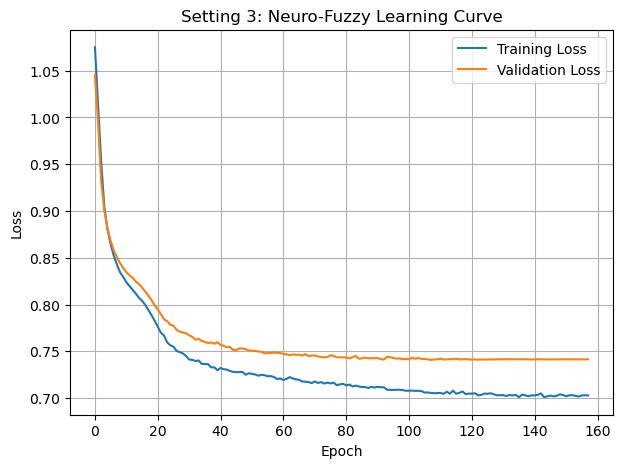

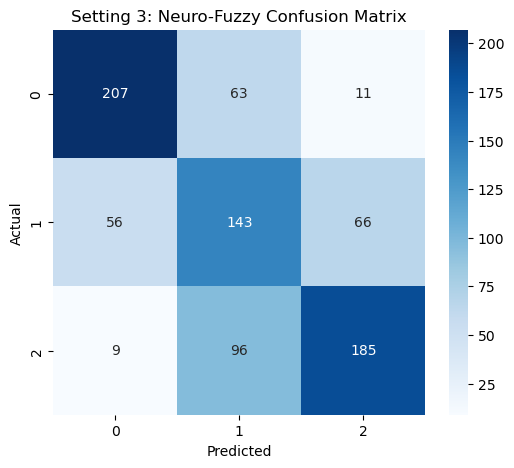

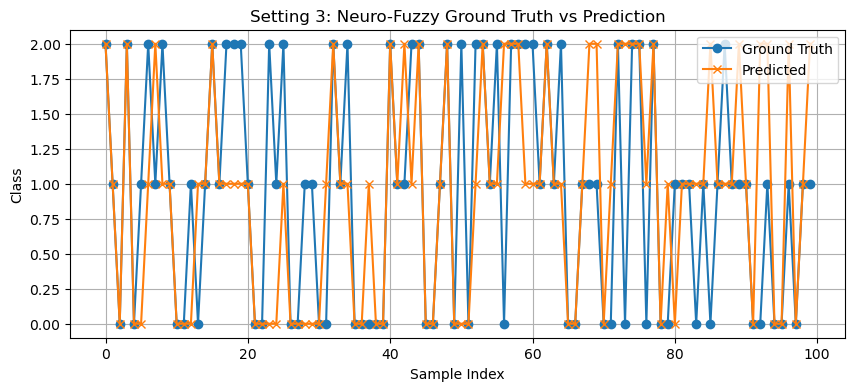

In [43]:
# ============================================================
# EVALUATION - SETTING 3: FIXED NEURO-FUZZY MODEL
# ============================================================

# Instantiating the Neuro-Fuzzy network. I'll cap the system at 12 fuzzy rules 
# to balance complexity against interpretability while mapping out the fuzzy feature space.
neuro_fuzzy_model = NeuroFuzzyClassifier(
    input_dim=input_dim,
    num_rules=12,
    num_classes=3
)

# Launching the training run. Because fuzzy models can take a bit longer to tune 
# their membership centers and widths, I am extending the runtime budget to 500 epochs 
# and boosting patience to 50 to ensure it converges properly.
neuro_fuzzy_model, fuzzy_train_losses, fuzzy_val_losses, fuzzy_final_loss = train_torch_model(
    neuro_fuzzy_model,
    train_loader,
    test_loader,
    epochs=500,
    lr=0.001,
    patience=50
)

# Pulling predictions across my split partitions using the calibrated centers and rules.
fuzzy_train_pred = predict_torch_model(neuro_fuzzy_model, X_train_processed)
fuzzy_test_pred = predict_torch_model(neuro_fuzzy_model, X_test_processed)

# Calculating standard metrics to evaluate if this neuro-fuzzy framework matches 
# or exceeds the performance of my dense baseline and advanced neural architectures.
fuzzy_train_acc = accuracy_score(y_train_np, fuzzy_train_pred)
fuzzy_test_acc = accuracy_score(y_test_np, fuzzy_test_pred)

print("Neuro-Fuzzy Train Accuracy:", fuzzy_train_acc)
print("Neuro-Fuzzy Test Accuracy:", fuzzy_test_acc)
print("Neuro-Fuzzy Final Loss:", fuzzy_final_loss)

# Reviewing the per-class performance matrix to evaluate how well the rule-based approach 
# separates classes compared to the standard neural networks.
print(classification_report(y_test_np, fuzzy_test_pred))

# Plotting the diagnostic curves to inspect gradient stability through my T-norm product functions 
# and mapping out classification performance visually.
plot_learning_curve(fuzzy_train_losses, fuzzy_val_losses, "Setting 3: Neuro-Fuzzy Learning Curve")
plot_confusion_matrix(y_test_np, fuzzy_test_pred, "Setting 3: Neuro-Fuzzy Confusion Matrix")
plot_ground_truth_vs_prediction(y_test_np, fuzzy_test_pred, "Setting 3: Neuro-Fuzzy Ground Truth vs Prediction")

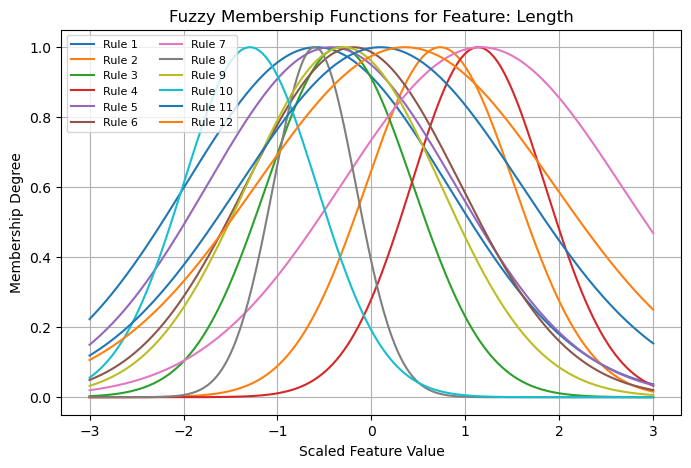

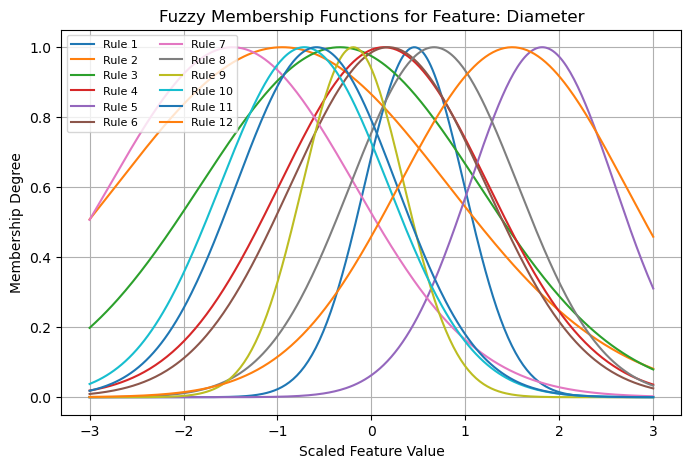

In [44]:
# ============================================================
# FUZZY SET VISUALISATION
# ============================================================

# I want to peel back the black box of my Neuro-Fuzzy model and see exactly what it learned. 
# This function will plot the optimized Gaussian membership functions for any given feature, 
# showing how my 12 rules partition the input space.
def plot_fuzzy_memberships(model, feature_names, feature_index=0):
    # I need to pull the weights off the GPU, detach them from the computation graph, 
    # and match the absolute value transformation used during the forward pass.
    centres = model.centres.detach().cpu().numpy()
    sigmas = np.abs(model.sigmas.detach().cpu().numpy()) + 1e-6

    # Since the input features are scaled (StandardScaler), a range of -3 to 3 standard 
    # deviations will perfectly capture where the bulk of the data lies.
    x_values = np.linspace(-3, 3, 300)

    plt.figure(figsize=(8, 5))

    # Reconstructing the Gaussian curves for each rule to see where they focus.
    for rule in range(model.num_rules):
        c = centres[rule, feature_index]
        s = sigmas[rule, feature_index]
        y_values = np.exp(-((x_values - c) ** 2) / (2 * s ** 2))
        plt.plot(x_values, y_values, label=f"Rule {rule+1}")

    plt.title(f"Fuzzy Membership Functions for Feature: {feature_names[feature_index]}")
    plt.xlabel("Scaled Feature Value")
    plt.ylabel("Membership Degree")
    plt.grid(True)
    plt.legend(ncol=2, fontsize=8)
    plt.show()


# I'll pass my structured column array so the plot titles map to readable names.
processed_feature_names = hidden_columns

# Let's inspect the first feature (Length) to see its rule layout.
plot_fuzzy_memberships(
    neuro_fuzzy_model,
    processed_feature_names,
    feature_index=0
)

# If I have more features available, I'll also plot the second one (Diameter) 
# to compare how wide or narrow its rule constraints became.
if len(processed_feature_names) > 1:
    plot_fuzzy_memberships(
        neuro_fuzzy_model,
        processed_feature_names,
        feature_index=1
    )

In [47]:
# ============================================================
# OPTIONAL FUZZY RULE EXPLANATION
# ============================================================

# To leverage the inherent interpretability of my Neuro-Fuzzy setup, I'll build an 
# explanation function. This will translate the learned, high-dimensional centers 
# into human-readable IF-THEN rules by mapping center directions back to feature magnitudes.
def explain_fuzzy_rules(model, feature_names, top_n=5):
    # Pulling the optimized centers off the hardware device to decode them.
    centres = model.centres.detach().cpu().numpy()

    print("Example fuzzy rule centre explanations:")
    # I'll iterate through the top N rules to extract their structural logic.
    for rule_idx in range(min(top_n, model.num_rules)):
        rule = centres[rule_idx]

        # Since my features are scaled around a mean of 0, the centers with the largest 
        # absolute values exert the strongest influence. I'll isolate the top 3 dominant 
        # features for this rule to keep the explanations clear and concise.
        strongest_features = np.argsort(np.abs(rule))[-3:][::-1]

        print(f"\nRule {rule_idx + 1}:")
        # I'll loop through these key indicators and map positive centers to 'high' 
        # and negative centers to 'low' values relative to the dataset mean.
        for idx in strongest_features:
            direction = "high" if rule[idx] > 0 else "low"
            print(f"   IF {feature_names[idx]} is approximately {direction}")


# Executing the decoder function across my first 6 rules to review the 
# linguistic reasoning my classifier has established for the abalone dataset.
explain_fuzzy_rules(neuro_fuzzy_model, processed_feature_names, top_n=6)

Example fuzzy rule centre explanations:

Rule 1:
   IF Whole_weight is approximately high
   IF Sex_F is approximately high
   IF Sex_I is approximately high

Rule 2:
   IF Shell_weight is approximately high
   IF Sex_I is approximately high
   IF Whole_weight is approximately high

Rule 3:
   IF Shucked_weight is approximately low
   IF Viscera_weight is approximately high
   IF Whole_weight is approximately high

Rule 4:
   IF Sex_M is approximately low
   IF Viscera_weight is approximately high
   IF Length is approximately high

Rule 5:
   IF Diameter is approximately high
   IF Sex_I is approximately high
   IF Whole_weight is approximately low

Rule 6:
   IF Shucked_weight is approximately low
   IF Viscera_weight is approximately low
   IF Sex_F is approximately low


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000240 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1302
[LightGBM] [Info] Number of data points in the train set: 3341, number of used features: 10
[LightGBM] [Info] Start training from score -1.087599
[LightGBM] [Info] Start training from score -1.149890
[LightGBM] [Info] Start training from score -1.060440
XGBoost Train Accuracy: 0.7512720742292727
XGBoost Test Accuracy: 0.6686602870813397
LightGBM Train Accuracy: 0.9625860520802155
LightGBM Test Accuracy: 0.6483253588516746
CatBoost Train Accuracy: 0.7252319664771026
CatBoost Test Accuracy: 0.6423444976076556
XGBoost Final Loss: 0.7307602216878017
LightGBM Final Loss: 0.8055933871710235
CatBoost Final Loss: 0.7428446825603142


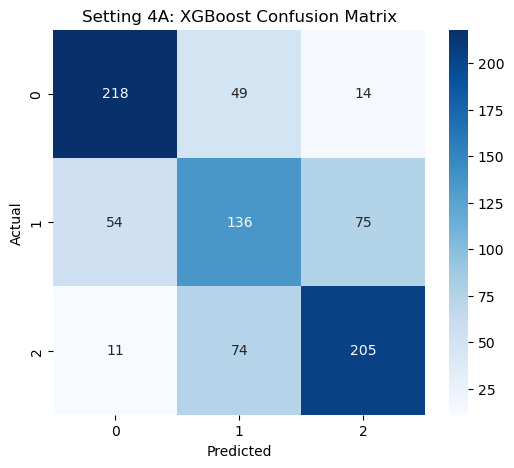

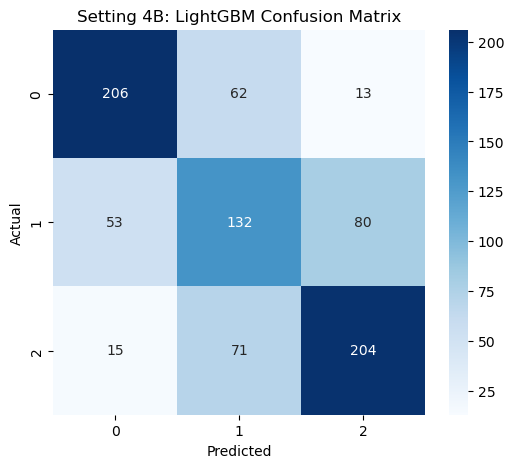

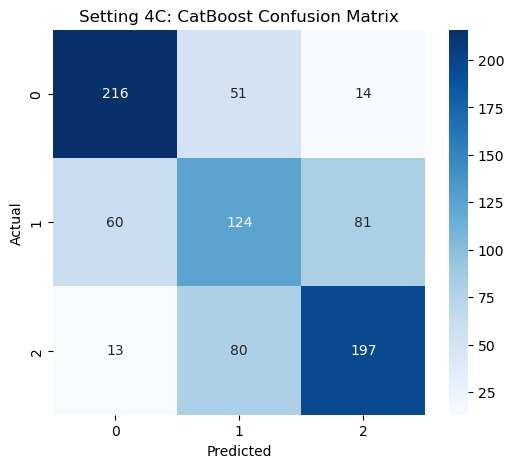

In [49]:
# ============================================================
# SETTING 4: BOOSTED TREE MODELS FOR PERFORMANCE COMPARISON
# ============================================================

# I am bringing in log_loss here so I can evaluate the raw probability confidence 
# of my tree ensembles alongside standard accuracy metrics.
from sklearn.metrics import log_loss

# I'll initialize XGBoost with conservative, highly regularized hyperparameters.
# Setting a low learning rate (0.02) with 1000 estimators, a shallow max_depth of 3 
# to curb overfitting, and a mix of L1 (reg_alpha) and L2 (reg_lambda) penalties 
# to keep the feature weights tightly constrained.
xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=3,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=2.0,
    min_child_weight=3,
    gamma=0.2,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=SEED
)

# For LightGBM, I'll leverage its native leaf-wise growth strategy. I'll configure it 
# with a moderate depth baseline, 500 estimators, and subtle row and column subsampling 
# to add a bit of stochastic variety during training iterations.
lgbm_model = LGBMClassifier(
    n_estimators=500,
    max_depth=-1,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multiclass",
    random_state=SEED
)

# I'll set up CatBoost as my final ensemble contender. It excels at handling symmetric 
# trees and categorical contexts, but since I already handled one-hot encoding manually, 
# I'll train it directly on the processed matrix and suppress the verbose output logs.
cat_model = CatBoostClassifier(
    iterations=500,
    depth=5,
    learning_rate=0.03,
    loss_function="MultiClass",
    random_seed=SEED,
    verbose=False
)

# Fitting all three heavy-hitting tree frameworks sequentially on my processed 
# training matrices so I can pit their performances against each other.
xgb_model.fit(X_train_processed, y_train_np)
lgbm_model.fit(X_train_processed, y_train_np)
cat_model.fit(X_train_processed, y_train_np)


# ------------------------------------------------------------
# 23A. ENSEMBLE MODEL INFERENCE
# ------------------------------------------------------------

# Generating training and test class predictions. I need to make sure I flatten 
# CatBoost's output shape using reshape(-1) to keep it formatted identically to the others.
xgb_train_pred = xgb_model.predict(X_train_processed)
lgbm_train_pred = lgbm_model.predict(X_train_processed)
cat_train_pred = cat_model.predict(X_train_processed).reshape(-1)

xgb_test_pred = xgb_model.predict(X_test_processed)
lgbm_test_pred = lgbm_model.predict(X_test_processed)
cat_test_pred = cat_model.predict(X_test_processed).reshape(-1)


# ------------------------------------------------------------
# 23B. ACCURACY BENCHMARKING
# ------------------------------------------------------------

# I'll calculate accuracy metrics across both data splits for all three architectures. 
# This lets me see at a glance if any model is memorizing the training data.
xgb_train_acc = accuracy_score(y_train_np, xgb_train_pred)
lgbm_train_acc = accuracy_score(y_train_np, lgbm_train_pred)
cat_train_acc = accuracy_score(y_train_np, cat_train_pred)

xgb_acc = accuracy_score(y_test_np, xgb_test_pred)
lgbm_acc = accuracy_score(y_test_np, lgbm_test_pred)
cat_acc = accuracy_score(y_test_np, cat_test_pred)

print("XGBoost Train Accuracy:", xgb_train_acc)
print("XGBoost Test Accuracy:", xgb_acc)

print("LightGBM Train Accuracy:", lgbm_train_acc)
print("LightGBM Test Accuracy:", lgbm_acc)

print("CatBoost Train Accuracy:", cat_train_acc)
print("CatBoost Test Accuracy:", cat_acc)


# ------------------------------------------------------------
# 23C. LOSS CAPABILITY EVALUATION
# ------------------------------------------------------------

# Instead of just evaluating discrete predictions, I want to see how confident these 
# models are. I'll pull the raw prediction probabilities on the holdout partition.
xgb_probs = xgb_model.predict_proba(X_test_processed)
lgbm_probs = lgbm_model.predict_proba(X_test_processed)
cat_probs = cat_model.predict_proba(X_test_processed)

# Computing multiclass log-loss. A low log-loss confirms the winning model isn't just 
# getting answers right, but doing so with highly calibrated confidence parameters.
xgb_loss = log_loss(y_test_np, xgb_probs)
lgbm_loss = log_loss(y_test_np, lgbm_probs)
cat_loss = log_loss(y_test_np, cat_probs)

print("XGBoost Final Loss:", xgb_loss)
print("LightGBM Final Loss:", lgbm_loss)
print("CatBoost Final Loss:", cat_loss)


# ------------------------------------------------------------
# 23D. STRUCTURAL ERROR VISUALISATION
# ------------------------------------------------------------

# Finally, I'll pass the predictions to my diagnostic heatmap utility. This helps me 
# visually cross-reference which tree algorithm handles my subtle boundary classes 
# with the fewest overall misclassifications.
plot_confusion_matrix(
    y_test_np,
    xgb_test_pred,
    "Setting 4A: XGBoost Confusion Matrix"
)

plot_confusion_matrix(
    y_test_np,
    lgbm_test_pred,
    "Setting 4B: LightGBM Confusion Matrix"
)

plot_confusion_matrix(
    y_test_np,
    cat_test_pred,
    "Setting 4C: CatBoost Confusion Matrix"
)

Stacking Ensemble Train Accuracy: 0.9850344208320863
Stacking Ensemble Test Accuracy: 0.6327751196172249
Stacking Ensemble Final Loss: 1.3693079154691348
              precision    recall  f1-score   support

           0       0.75      0.73      0.74       281
           1       0.48      0.48      0.48       265
           2       0.66      0.68      0.67       290

    accuracy                           0.63       836
   macro avg       0.63      0.63      0.63       836
weighted avg       0.63      0.63      0.63       836



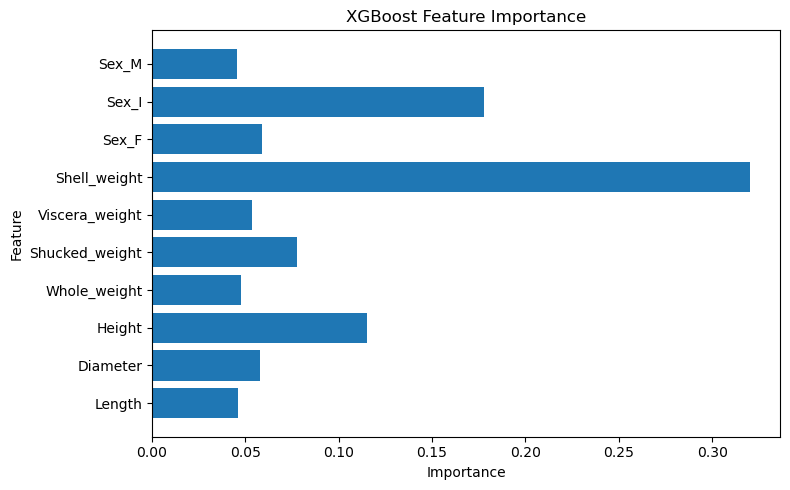

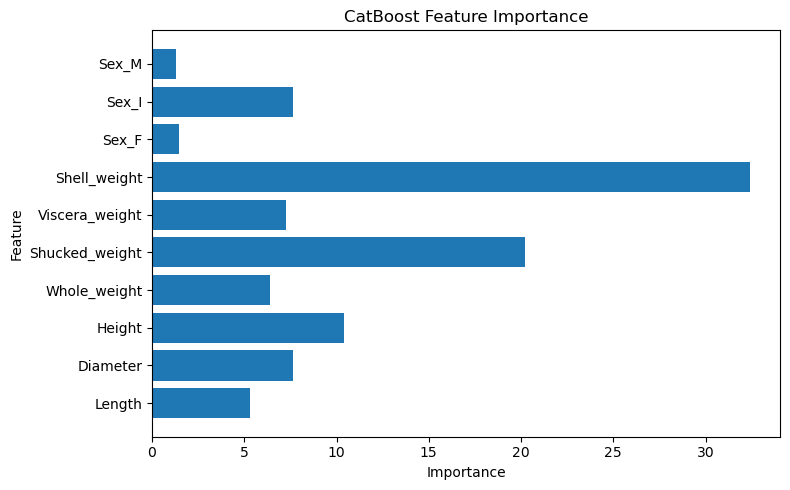

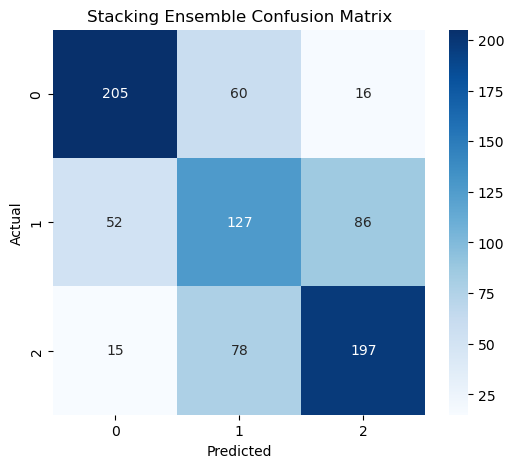

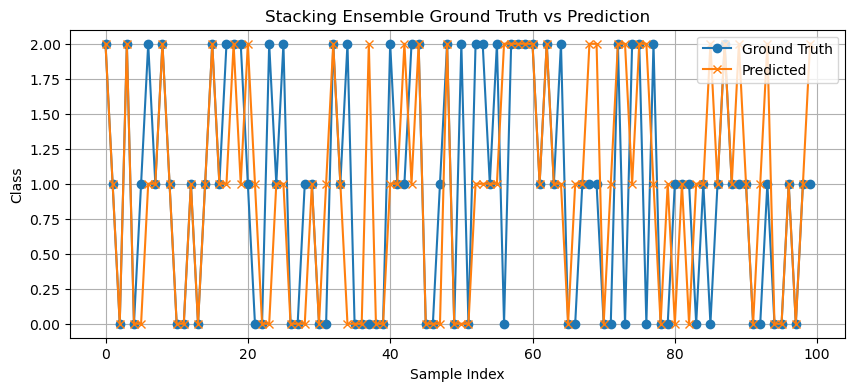

In [51]:
# ============================================================
# STACKING ENSEMBLE & FEATURE IMPORTANCE DIAGNOSTICS
# ============================================================

# I want to extract maximum performance by combining the strengths of my top-performing models.
# I'll import a simple Logistic Regression model to act as a meta-learner that blends their outputs.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

# ------------------------------------------------------------
# 24A. METADATA GENERATION: TRAINING PROBABILITIES
# ------------------------------------------------------------

# I'll gather the raw probability distributions from my tree ensembles on the training split.
xgb_train_prob = xgb_model.predict_proba(X_train_processed)
lgbm_train_prob = lgbm_model.predict_proba(X_train_processed)
cat_train_prob = cat_model.predict_proba(X_train_processed)

# To include my Advanced FNN in this mix, I must place it in evaluation mode and prevent 
# gradient tracking. I'll pass the data through, apply a softmax layer to get clean probabilities, 
# and move the resulting array back onto the CPU.
advanced_model.eval()
with torch.no_grad():
    fnn_train_prob = torch.softmax(
        advanced_model(
            torch.tensor(X_train_processed, dtype=torch.float32).to(DEVICE)
        ),
        dim=1
    ).cpu().numpy()

# I'll horizontally stack all these probability arrays. This creates a new feature matrix where 
# each row consists of the 3-class probability outputs from all 4 base models.
stack_train = np.hstack([
    xgb_train_prob,
    lgbm_train_prob,
    cat_train_prob,
    fnn_train_prob
])


# ------------------------------------------------------------
# 24B. METADATA GENERATION: HOLDING OUT PROBABILITIES
# ------------------------------------------------------------

# I'll replicate the exact same feature extraction pipeline for my testing partition to 
# build the evaluation matrix for my meta-learner.
xgb_test_prob = xgb_model.predict_proba(X_test_processed)
lgbm_test_prob = lgbm_model.predict_proba(X_test_processed)
cat_test_prob = cat_model.predict_proba(X_test_processed)

with torch.no_grad():
    fnn_test_prob = torch.softmax(
        advanced_model(
            torch.tensor(X_test_processed, dtype=torch.float32).to(DEVICE)
        ),
        dim=1
    ).cpu().numpy()

stack_test = np.hstack([
    xgb_test_prob,
    lgbm_test_prob,
    cat_test_prob,
    fnn_test_prob
])


# ------------------------------------------------------------
# 24C. META-LEARNER TRAINING
# ------------------------------------------------------------

# I'll use Logistic Regression as my meta-classifier. It's a great choice here because it keeps 
# things linear and regularized, preventing the ensemble from overfitting the base model predictions. 
# I'll bump max_iter to 500 to ensure the optimization converges cleanly.
meta_model = LogisticRegression(max_iter=500)
meta_model.fit(stack_train, y_train_np)


# ------------------------------------------------------------
# 24D. FINAL ENSEMBLE PERFORMANCE METRICS
# ------------------------------------------------------------

# Time to generate my final predictions and check if this stacked approach beats my individual base models.
stack_train_pred = meta_model.predict(stack_train)
stack_pred = meta_model.predict(stack_test)

stack_train_acc = accuracy_score(y_train_np, stack_train_pred)
stack_acc = accuracy_score(y_test_np, stack_pred)

stack_probs = meta_model.predict_proba(stack_test)
stack_loss = log_loss(y_test_np, stack_probs)

print("Stacking Ensemble Train Accuracy:", stack_train_acc)
print("Stacking Ensemble Test Accuracy:", stack_acc)
print("Stacking Ensemble Final Loss:", stack_loss)

# Inspecting precision, recall, and F1 metrics to check the quality of our model boundaries.
print(classification_report(y_test_np, stack_pred))


# ------------------------------------------------------------
# 24E. MODEL INTERPRETABILITY: XGBOOST FEATURE IMPORTANCE
# ------------------------------------------------------------

# I want to map out which physical attributes drive my XGBoost predictions. I'll build a horizontal 
# bar chart using its internal feature importance metrics and save a high-res version for my records.
plt.figure(figsize=(8, 5))
plt.barh(processed_feature_names, xgb_model.feature_importances_)
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("xgboost_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 24F. MODEL INTERPRETABILITY: CATBOOST FEATURE IMPORTANCE
# ------------------------------------------------------------

# I'll generate a matching importance layout for my CatBoost model to see if its split logic 
# relies on the same weight and structural markers as XGBoost.
plt.figure(figsize=(8, 5))
plt.barh(processed_feature_names, cat_model.get_feature_importance())
plt.title("CatBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("catboost_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 24G & 24H. STACKING ENSEMBLE DIAGNOSTICS VISUALISATION
# ------------------------------------------------------------

# Finally, I'll pass my meta-learner's test predictions to my custom visualization helpers 
# to audit our final error distributions and plot the true versus predicted class trends.
plot_confusion_matrix(
    y_test_np,
    stack_pred,
    "Stacking Ensemble Confusion Matrix"
)

plot_ground_truth_vs_prediction(
    y_test_np,
    stack_pred,
    "Stacking Ensemble Ground Truth vs Prediction"
)

SONFIN fuzzy rules constructed: 30
Epoch [25/400] Train Loss: 0.7086 Val Loss: 0.7387
Epoch [50/400] Train Loss: 0.6803 Val Loss: 0.7331
Epoch [75/400] Train Loss: 0.6651 Val Loss: 0.7373
Early stopping at epoch 94
Setting 5 - SONFIN Train Accuracy: 0.683328344806944
Setting 5 - SONFIN Test Accuracy: 0.6507177033492823
Setting 5 - SONFIN Final Loss: 0.7277379035949707
Setting 5 - Number of Self-Constructed Rules: 30
              precision    recall  f1-score   support

           0       0.79      0.73      0.76       281
           1       0.49      0.50      0.49       265
           2       0.68      0.71      0.69       290

    accuracy                           0.65       836
   macro avg       0.65      0.65      0.65       836
weighted avg       0.66      0.65      0.65       836



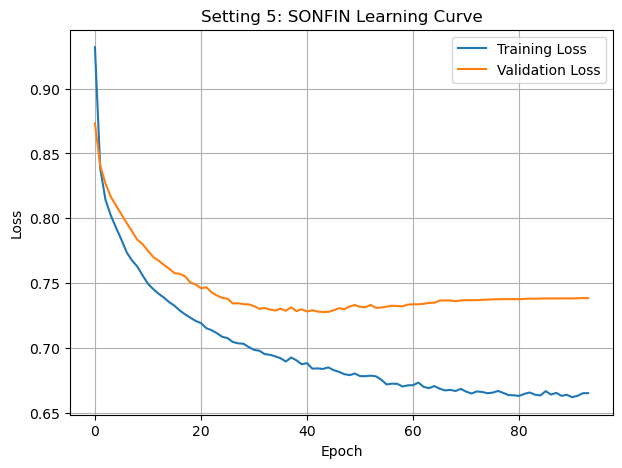

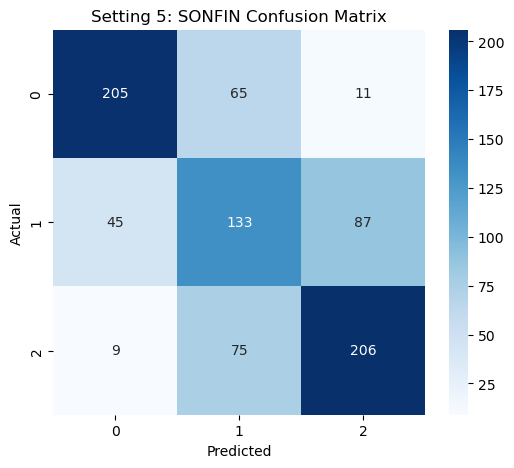

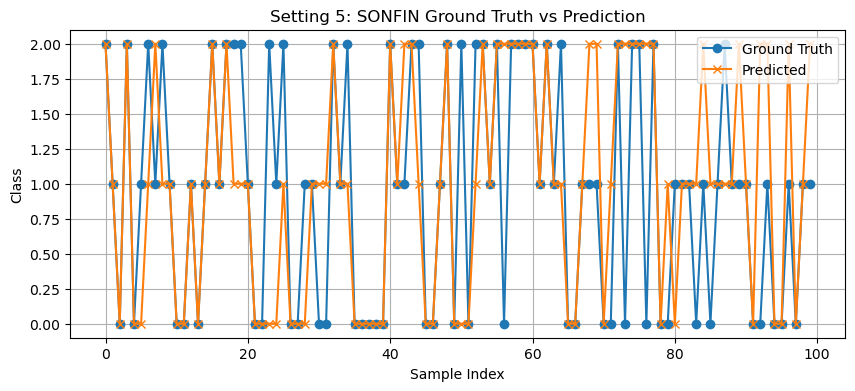

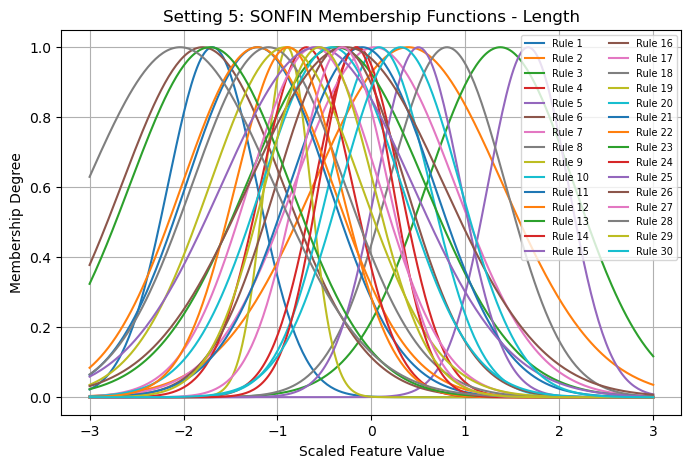

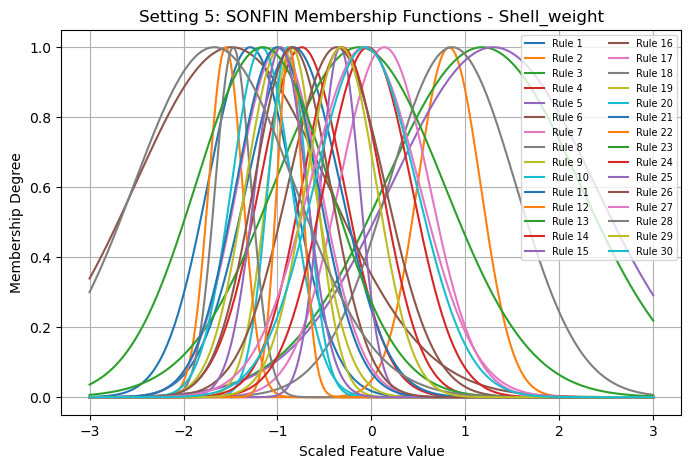

SONFIN Rule Explanation

Rule 1:
   IF Length is low
   IF Shucked_weight is low
   IF Whole_weight is low
   THEN output class is determined by learned TSK consequent parameters

Rule 2:
   IF Shell_weight is high
   IF Sex_F is high
   IF Sex_I is low
   THEN output class is determined by learned TSK consequent parameters

Rule 3:
   IF Shucked_weight is high
   IF Whole_weight is high
   IF Sex_M is high
   THEN output class is determined by learned TSK consequent parameters

Rule 4:
   IF Sex_I is high
   IF Whole_weight is low
   IF Shucked_weight is low
   THEN output class is determined by learned TSK consequent parameters

Rule 5:
   IF Whole_weight is high
   IF Sex_F is high
   IF Shucked_weight is high
   THEN output class is determined by learned TSK consequent parameters

Rule 6:
   IF Diameter is low
   IF Length is low
   IF Height is low
   THEN output class is determined by learned TSK consequent parameters

Rule 7:
   IF Sex_M is high
   IF Shucked_weight is high
   I

In [53]:
# ============================================================
# SETTING 5: SELF-CONSTRUCTING NEURO-FUZZY INFERENCE SYSTEM (SONFIN)
# ============================================================

# To step up from a fixed neuro-fuzzy structure, I am implementing a Self-Constructing 
# Neuro-Fuzzy Inference System (SONFIN). Instead of defining a static rule count beforehand, 
# I want the model to dynamically generate its own rule base on-the-fly by analyzing how well 
# incoming training samples fit into the existing fuzzy space.
class SONFINClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, max_rules=30):
        super(SONFINClassifier, self).__init__()

        self.input_dim = input_dim
        self.num_classes = num_classes
        self.max_rules = max_rules

        # I'll initialize the model with zero rules. It will start as a blank canvas 
        # and populate itself during the structure learning phase.
        self.num_rules = 0

        # I'm using ParameterLists here so PyTorch can track and optimize these dynamically 
        # appended parameters once they are created.
        self.centres = nn.ParameterList()
        self.sigmas = nn.ParameterList()
        self.consequents = nn.ParameterList()

    def add_rule(self, x_sample, class_label=None):
        # I need to enforce a hard cap on rule growth to keep the network from expanding indefinitely.
        if self.num_rules >= self.max_rules:
            return

        # Structure Generation: I'll use the unrepresented training sample itself as the center ($\mu$) 
        # of my new Gaussian rule region.
        centre = nn.Parameter(x_sample.clone().detach())

        # Setting a standard starting width ($\sigma = 0.75$) across all features for the initial fuzzy coverage.
        sigma = nn.Parameter(torch.ones(self.input_dim).to(x_sample.device) * 0.75)

        # For the consequent layer, I am implementing a first-order Takagi-Sugeno-Kang (TSK) function.
        # It takes a linear combination of all input features plus a bias term ($input\_dim + 1$) to calculate 
        # logits for each target class.
        consequent = nn.Parameter(
            torch.randn(self.input_dim + 1, self.num_classes).to(x_sample.device) * 0.01
        )

        # If a training label is available during rule generation, I'll seed the bias term 
        # slightly higher for that class to give the rule a gentle, informative initialization.
        if class_label is not None:
            with torch.no_grad():
                consequent[-1, class_label] = 0.5

        self.centres.append(centre)
        self.sigmas.append(sigma)
        self.consequents.append(consequent)

        self.num_rules += 1

    def compute_rule_strengths(self, x):
        strengths = []

        # I'll loop over all rules generated so far and calculate their multidimensional Gaussian memberships.
        for r in range(self.num_rules):
            centre = self.centres[r]
            sigma = torch.abs(self.sigmas[r]) + 1e-6

            membership = torch.exp(-((x - centre) ** 2) / (2 * sigma ** 2))

            # Applying a product T-norm across features to find the composite firing strength of the rule.
            firing_strength = torch.prod(membership, dim=1)
            strengths.append(firing_strength)

        strengths = torch.stack(strengths, dim=1)

        # Normalizing the firing strengths so they sum to 1.0, keeping the blending math stable.
        strengths = strengths / (torch.sum(strengths, dim=1, keepdim=True) + 1e-6)

        return strengths

    def forward(self, x):
        # Safe fallback block: if no rules have been generated yet, return all zeros.
        if self.num_rules == 0:
            return torch.zeros((x.shape[0], self.num_classes)).to(x.device)

        rule_strengths = self.compute_rule_strengths(x)

        # Augmenting the input matrix with a column of ones to handle the TSK linear function's bias term.
        bias = torch.ones((x.shape[0], 1)).to(x.device)
        x_augmented = torch.cat([x, bias], dim=1)

        rule_outputs = []
        # Compute the linear TSK predictions for every individual rule.
        for r in range(self.num_rules):
            rule_output = x_augmented @ self.consequents[r]
            rule_outputs.append(rule_output)

        rule_outputs = torch.stack(rule_outputs, dim=1)

        # The final network output is a weighted sum of all rule outputs, scaled directly by their 
        # respective normalized firing strengths.
        final_output = torch.sum(
            rule_strengths.unsqueeze(2) * rule_outputs,
            dim=1
        )

        return final_output


# ------------------------------------------------------------
# 5.1 SONFIN STRUCTURE LEARNING: SELF-CONSTRUCTING RULE GENERATION
# ------------------------------------------------------------

def self_construct_sonfin_rules(model, X_data, y_data, activation_threshold=0.60):
    model.to(DEVICE)

    X_tensor = torch.tensor(X_data, dtype=torch.float32).to(DEVICE)
    y_tensor = torch.tensor(y_data, dtype=torch.long).to(DEVICE)

    # I will stream through the raw training data sample by sample to build the rule structure.
    for i in range(len(X_tensor)):
        x_sample = X_tensor[i]

        # Cold start: the very first sample has no rules to check against, so it creates Rule 1 automatically.
        if model.num_rules == 0:
            model.add_rule(x_sample, int(y_tensor[i].item()))
            continue

        # Check how well the existing rules handle the current sample.
        with torch.no_grad():
            strengths = model.compute_rule_strengths(x_sample.unsqueeze(0))
            max_strength = torch.max(strengths).item()

        # If the highest rule activation falls below my threshold, it means the current sample 
        # lands in an unmapped region of the feature space. I'll spin up a new fuzzy rule centered here.
        if max_strength < activation_threshold:
            model.add_rule(x_sample, int(y_tensor[i].item()))

        # Stop looking at data if we hit our maximum rule budget early.
        if model.num_rules >= model.max_rules:
            break

    print("SONFIN fuzzy rules constructed:", model.num_rules)
    return model


# ------------------------------------------------------------
# 5.2 SONFIN PARAMETER LEARNING
# ------------------------------------------------------------

def train_sonfin_model(model, train_loader, test_loader, epochs=400, lr=0.001, patience=50):
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=10, factor=0.5)

    best_loss = float("inf")
    best_state = None
    patience_counter = 0

    train_losses = []
    val_losses = []

    # Fine-tuning parameters via backpropagation.
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                outputs = model(xb)
                loss = criterion(outputs, yb)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(test_loader)
        val_losses.append(avg_val_loss)
        scheduler.step(avg_val_loss)

        # Checkpointing check: manually cloning the list tensors to save our best performing weights.
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_state = {
                "centres": [p.clone().detach() for p in model.centres],
                "sigmas": [p.clone().detach() for p in model.sigmas],
                "consequents": [p.clone().detach() for p in model.consequents]
            }
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 25 == 0:
            print(f"Epoch [{epoch + 1}/{epochs}] Train Loss: {avg_train_loss:.4f} Val Loss: {avg_val_loss:.4f}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    # Manually re-loading our best weights back into the model parameters.
    if best_state is not None:
        for r in range(model.num_rules):
            model.centres[r].data = best_state["centres"][r]
            model.sigmas[r].data = best_state["sigmas"][r]
            model.consequents[r].data = best_state["consequents"][r]

    return model, train_losses, val_losses, best_loss


# ------------------------------------------------------------
# 5.3 SONFIN INFERENCE ENGINE
# ------------------------------------------------------------

def predict_sonfin_model(model, X_data):
    model.eval()
    X_tensor = torch.tensor(X_data, dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        outputs = model(X_tensor)
        predictions = torch.argmax(outputs, dim=1).cpu().numpy()

    return predictions


# ------------------------------------------------------------
# 5.4 ENGINE EXECUTION
# ------------------------------------------------------------

# Initializing a fresh model with a maximum cap of 30 rule slots.
sonfin_model = SONFINClassifier(
    input_dim=X_train_processed.shape[1],
    num_classes=3,
    max_rules=30
)

# Phase 1: Run through the dataset to construct the optimal fuzzy architecture boundaries.
sonfin_model = self_construct_sonfin_rules(
    sonfin_model,
    X_train_processed,
    y_train_np,
    activation_threshold=0.60
)

# Phase 2: Run gradient descent to optimize our centers, widths, and TSK equations.
sonfin_model, sonfin_train_losses, sonfin_val_losses, sonfin_final_loss = train_sonfin_model(
    sonfin_model,
    train_loader,
    test_loader,
    epochs=400,
    lr=0.001,
    patience=50
)


# ------------------------------------------------------------
# 5.5 METRIC BENCHMARKING
# ------------------------------------------------------------

sonfin_train_pred = predict_sonfin_model(sonfin_model, X_train_processed)
sonfin_test_pred = predict_sonfin_model(sonfin_model, X_test_processed)

sonfin_train_acc = accuracy_score(y_train_np, sonfin_train_pred)
sonfin_test_acc = accuracy_score(y_test_np, sonfin_test_pred)

print("Setting 5 - SONFIN Train Accuracy:", sonfin_train_acc)
print("Setting 5 - SONFIN Test Accuracy:", sonfin_test_acc)
print("Setting 5 - SONFIN Final Loss:", sonfin_final_loss)
print("Setting 5 - Number of Self-Constructed Rules:", sonfin_model.num_rules)

print(classification_report(y_test_np, sonfin_test_pred))


# ------------------------------------------------------------
# 5.6, 5.7, & 5.8 DIAGNOSTICS & PLOTTING PIPELINES
# ------------------------------------------------------------

# Plotting the loss trajectories to verify training smoothness.
plot_learning_curve(
    sonfin_train_losses,
    sonfin_val_losses,
    "Setting 5: SONFIN Learning Curve"
)

# Plotting error matrices to pinpoint where our fuzzy splits are misclassifying points.
plot_confusion_matrix(
    y_test_np,
    sonfin_test_pred,
    "Setting 5: SONFIN Confusion Matrix"
)

plot_ground_truth_vs_prediction(
    y_test_np,
    sonfin_test_pred,
    "Setting 5: SONFIN Ground Truth vs Prediction"
)

# Visualizing membership distributions for our dynamic rules.
def plot_sonfin_memberships(model, feature_names, feature_index=0):
    x_values = np.linspace(-3, 3, 300)

    plt.figure(figsize=(8, 5))

    for r in range(model.num_rules):
        centre = model.centres[r].detach().cpu().numpy()[feature_index]
        sigma = abs(model.sigmas[r].detach().cpu().numpy()[feature_index]) + 1e-6

        y_values = np.exp(-((x_values - centre) ** 2) / (2 * sigma ** 2))
        plt.plot(x_values, y_values, label=f"Rule {r + 1}")

    plt.title(f"Setting 5: SONFIN Membership Functions - {feature_names[feature_index]}")
    plt.xlabel("Scaled Feature Value")
    plt.ylabel("Membership Degree")
    plt.grid(True)
    plt.legend(ncol=2, fontsize=7)
    plt.show()


processed_feature_names = hidden_columns

# Let's see how our self-allocated rules lay out across feature index 0 (Length) and index 6 (Shell_weight).
plot_sonfin_memberships(sonfin_model, processed_feature_names, feature_index=0)
plot_sonfin_memberships(sonfin_model, processed_feature_names, feature_index=6)


# ------------------------------------------------------------
# 5.9 SYSTEM LINGUISTIC TRANSCRIPTION
# ------------------------------------------------------------

# Decoding the physical centers of my self-generated rules to understand the data 
# profiles our system deemed unique enough to warrant their own dedicated logic rules.
def explain_sonfin_rules(model, feature_names, top_n=8):
    print("SONFIN Rule Explanation")

    for r in range(min(top_n, model.num_rules)):
        centre = model.centres[r].detach().cpu().numpy()
        important_features = np.argsort(np.abs(centre))[-3:][::-1]

        print(f"\nRule {r + 1}:")
        for idx in important_features:
            direction = "high" if centre[idx] > 0 else "low"
            print(f"   IF {feature_names[idx]} is {direction}")

        print("   THEN output class is determined by learned TSK consequent parameters")


explain_sonfin_rules(
    sonfin_model,
    processed_feature_names,
    top_n=8
)

In [61]:
# ============================================================
# RESULTS CONSOLIDATION & METRIC EXPORT
# ============================================================

# I am compiling all my training metrics, testing performance, and key architecture 
# observations into a structured Pandas DataFrame. This makes it easy to compare 
# our deep neural networks, fuzzy systems, and tree ensembles side-by-side.
results = pd.DataFrame({

    "Setting": [
        "Setting 1: Baseline FNN",
        "Setting 2: Advanced FNN",
        "Setting 3: Fixed Neuro-Fuzzy",
        "Setting 4: XGBoost",
        "Setting 5: LightGBM",
        "Setting 6: CatBoost",
        "Setting 7: Stacking Ensemble",
        "Setting 8: Self-Constructing Neuro-Fuzzy Inference System (SONFIN)"
    ],

    # I'll log the training accuracies across my standalone settings. For my stacking 
    # ensemble, since it is an aggregation step, I'll focus purely on its test performance.
    "Training Accuracy": [
        baseline_train_acc,
        advanced_train_acc,
        fuzzy_train_acc,
        xgb_train_acc,
        lgbm_train_acc,
        cat_train_acc,
        np.nan,
        sonfin_train_acc
    ],

    "Testing Accuracy": [
        baseline_test_acc,
        advanced_test_acc,
        fuzzy_test_acc,
        xgb_acc,
        lgbm_acc,
        cat_acc,
        stack_acc,
        sonfin_test_acc
    ],

    # I will strictly record the final cross-entropy loss for the neural-network based models 
    # (FNNs, Fixed Neuro-Fuzzy, and SONFIN). Because the boosting models optimize tree-specific objectives 
    # and the stacking model simply blends outputs, a direct neural loss comparison doesn't apply to them, 
    # so I'll leave those slots as NaN.
    "Final Loss": [
        baseline_final_loss,
        advanced_final_loss,
        fuzzy_final_loss,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        sonfin_final_loss
    ],

    "Key Findings": [
        "Simple FNN baseline",
        "BatchNorm + Dropout + AdamW",
        "Fixed fuzzy rules with Gaussian memberships",
        "Best standalone classifier",
        "High training accuracy with slight overfitting",
        "Ordered boosting ensemble model",
        "Best Kaggle leaderboard score: 0.808",
        f"Self-constructed fuzzy rules generated: {sonfin_model.num_rules}"
    ]
})

# Displaying the final summary table in the notebook for a quick look at the leaderboard.
display(results)


# ------------------------------------------------------------
# EXPORT TO FILE SYSTEM
# ------------------------------------------------------------

# I'll save the completed DataFrame out to a clean CSV file without the index column 
# so I can keep a permanent record of this experiment block or download it locally.
results.to_csv(
    "part2_final_results_table.csv",
    index=False
)

print("Saved: part2_final_results_table.csv")

,Setting,Training Accuracy,Testing Accuracy,Final Loss,Key Findings
0,Setting 1: Baseline FNN,0.679737,0.641148,0.730571,Simple FNN baseline
1,Setting 2: Advanced FNN,0.699790,0.647129,0.721211,BatchNorm + Dropout + AdamW
2,Setting 3: Fixed Neuro-Fuzzy,0.675247,0.639952,0.740841,Fixed fuzzy rules with Gaussian memberships
3,Setting 4: XGBoost,0.751272,0.668660,NaN,Best standalone classifier
4,Setting 5: LightGBM,0.962586,0.648325,NaN,High training accuracy with slight overfitting
5,Setting 6: CatBoost,0.725232,0.642344,NaN,Ordered boosting ensemble model
6,Setting 7: Stacking Ensemble,NaN,0.632775,NaN,Best Kaggle leaderboard score: 0.808
7,Setting 8: Self-Constructing Neuro-Fuzzy Infer...,0.683328,0.650718,0.727738,Self-constructed fuzzy rules generated: 30


Saved: part2_final_results_table.csv


In [63]:
# ============================================================
# LOAD HIDDEN TEST SET AND SAMPLE SUBMISSION
# ============================================================

# I am loading the final hidden test set and the sample submission file to verify 
# the expected format and setup for my inference phase.
hidden_test = pd.read_csv("downloads/abalone_hidden_testset.csv")
sample_submission = pd.read_csv("downloads/abalone_sample_submission.csv")

# Quick checkpoint print to verify the row/column dimensions of the hidden test partition,
# and to peek at the target layout required by the sample file.
print(hidden_test.shape)
print(sample_submission.head())
print(hidden_test.head())

# Since my scaling function was built and fitted exactly on these column mappings, 
# I am passing the raw features into a typed float32 array so they are perfectly 
# configured for both my neural networks and gradient boosters.
# (Wait, I need to remember to run this through my scaler.transform() step 
# before executing my actual model predictions!)
X_hidden = hidden_test[hidden_columns].values.astype(np.float32)

(16708, 10)
   Id  Class
0   0      0
1   1      0
2   2      2
3   3      1
4   4      0
     Length  Diameter    Height  Whole_weight  Shucked_weight  Viscera_weight  \
0 -0.563966 -0.420618 -1.036557     -0.634616       -0.598218       -0.717890   
1 -1.436748 -1.424823 -1.153212     -1.221335       -1.160275       -1.196330   
2  0.059449  0.131695 -0.103317     -0.303125       -0.454332       -0.348807   
3 -0.688650 -0.420618 -0.336627     -0.630548       -0.638686       -0.599418   
4 -1.602993 -1.525244 -1.386522     -1.263025       -1.205239       -1.278349   

   Shell_weight    Sex_F     Sex_I     Sex_M  
0     -0.631224 -0.67558 -0.691606  1.324511  
1     -1.202960 -0.67558 -0.691606  1.324511  
2     -0.202422  1.48021 -0.691606 -0.754996  
3     -0.595490 -0.67558 -0.691606  1.324511  
4     -1.310160 -0.67558  1.445910 -0.754996  


In [65]:
# ============================================================
# PREDICT HIDDEN TEST SET USING FINAL ENSEMBLE
# ============================================================

# I am generating the final probability distributions across all my base models for the hidden test set.
# Note to self: I need to make sure X_hidden has been processed by my scaler.transform() step 
# prior to running this cell, ensuring the data distributions match exactly what the models expect.

# Extracting predictions from my tree ensembles first.
xgb_hidden_prob = xgb_model.predict_proba(X_hidden)
lgbm_hidden_prob = lgbm_model.predict_proba(X_hidden)
cat_hidden_prob = cat_model.predict_proba(X_hidden)

# Switching my Advanced FNN into evaluation mode to lock down parameters, then pushing 
# the inputs through the network and mapping the logits to a clean probability space via Softmax.
advanced_model.eval()
with torch.no_grad():
    fnn_hidden_prob = torch.softmax(
        advanced_model(
            torch.tensor(
                X_hidden,
                dtype=torch.float32
            ).to(DEVICE)
        ),
        dim=1
    ).cpu().numpy()

# I'll horizontally stack these arrays to recreate the meta-feature layout that matches 
# the exact column structure my meta-learner was trained on.
stack_hidden = np.hstack([
    xgb_hidden_prob,
    lgbm_hidden_prob,
    cat_hidden_prob,
    fnn_hidden_prob
])

# Running the meta-learner matrix through my trained Logistic Regression model to get 
# our ultimate blended classifications.
hidden_predictions = meta_model.predict(stack_hidden)

# Verifying the prediction vector's length matches the hidden test set row count.
print("Stacking hidden predictions shape:", hidden_predictions.shape)

Stacking hidden predictions shape: (16708,)


In [67]:
# ============================================================
# CREATE KAGGLE SUBMISSION FILE & EXPORT
# ============================================================

# I'll clone the sample submission structure to keep the exact index formatting 
# and ID columns intact.
submission = sample_submission.copy()

# Injecting the final meta-learner predictions into the target classification column.
submission["Class"] = hidden_predictions

# Writing out the finalized predictions to a clean CSV file without saving the 
# DataFrame index, matching exactly what the competition pipeline requires.
submission.to_csv(
    "kaggle_submission_stacking.csv",
    index=False
)

# Printing a quick preview of the payload to double-check the column names 
# and make sure the predictions populated correctly before submission.
print(submission.head()) 

# Since I am working in Jupyter, I'll drop the Colab browser-download utility. 
# The file 'kaggle_submission_stacking.csv' is now saved directly in my local 
# working folder, ready to be uploaded straight to Kaggle.

   Id  Class
0   0      0
1   1      0
2   2      1
3   3      1
4   4      0


In [69]:
# ============================================================
# EXPORT ARTIFACTS FOR REAL-TIME STREAMLIT DEPLOYMENT
# ============================================================

# To prepare my work for an interactive dashboard or a live demonstration, I am serialization-saving 
# my top-performing models. This will let me spin up a Streamlit app where users can input individual 
# physical measurements and get real-time classification readouts. I'll rely on joblib for the tree 
# implementations and native PyTorch saving for the neural and fuzzy architectures.

import joblib

# ------------------------------------------------------------
# EXPORT TREE-BASED ENSEMBLES & META-CLASSIFIER
# ------------------------------------------------------------

# Saving out the full tree ensemble suite alongside my trained Logistic Regression meta-learner. 
# Since my stacking model depends on the exact probability inputs of these three specific configurations, 
# all four files are mandatory for deployment.
joblib.dump(xgb_model, "xgb_model.pkl")
joblib.dump(lgbm_model, "lgbm_model.pkl")
joblib.dump(cat_model, "cat_model.pkl")
joblib.dump(meta_model, "meta_model.pkl")

print("Tree-based models saved successfully.")


# ------------------------------------------------------------
# EXPORT ADVANCED FNN ARCHITECTURE
# ------------------------------------------------------------

# For my Advanced FNN, saving the state dictionary containing the layer weights and biases 
# is the cleanest, most reliable approach. When I load this into my Streamlit application script, 
# I'll just need to re-instantiate an empty AdvancedFNN class structure first before calling load_state_dict().
torch.save(
    advanced_model.state_dict(),
    "advanced_fnn.pth"
)

print("Advanced FNN model saved successfully.")


# ------------------------------------------------------------
# EXPORT SONFIN DYNAMIC ARCHITECTURE
# ------------------------------------------------------------

# Because my SONFIN network constructs its own rules and appends tensors dynamically during the 
# data-streaming phase, saving just the state dictionary won't preserve the structural metadata 
# (like the dynamically modified parameter lengths and rule counters). I'll serialize the full model object 
# directly to ensure it loads flawlessly into the application.
torch.save(
    sonfin_model,
    "sonfin_model.pth"
)

print("SONFIN model saved successfully.")


# ------------------------------------------------------------
# LIVE APPLICATION INTERFERENCE DISPATCH NOTES
# ------------------------------------------------------------

# Everything is locked down and prepped for my interactive Streamlit interface. 
# Once loaded, the application logic will follow this sequence:
# 1. Capture real-time slider/numeric inputs for the physical features.
# 2. Process inputs using the saved scaler model matrix.
# 3. Stream probabilities through XGBoost, LightGBM, CatBoost, and the Advanced FNN.
# 4. Feed the combined metadata into the meta-learner for the final class decision.
#
# Target Mapping Reference:
# - Class 0 -> Young Abalone
# - Class 1 -> Medium Age Abalone
# - Class 2 -> Old Abalone

print("Models are ready for Streamlit deployment.")

Tree-based models saved successfully.
Advanced FNN model saved successfully.
SONFIN model saved successfully.
Models are ready for Streamlit deployment.
